In [10]:
import zipfile
import os
from google.colab import files # Keep this import for potential future use or if 'uploaded' needs re-evaluation

# Assuming 'uploaded' dict already contains the file 'AMCD' from a previous successful upload.
# If 'uploaded' is empty or doesn't contain 'AMCD', you might need to re-run files.upload() in a separate cell.

if 'AMCD' in uploaded:
    zip_filename = 'AMCD' # The key in the 'uploaded' dictionary
    zip_local_path = os.path.join("/content/", zip_filename)

    # Ensure the extract_path exists
    extract_path = "/content/dataset"
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    try:
        # Write the uploaded content to a file on disk for zipfile to read
        with open(zip_local_path, 'wb') as f:
            f.write(uploaded[zip_filename])

        with zipfile.ZipFile(zip_local_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Dataset extracted successfully to '/content/dataset'!")
        print(f"Contents of extracted dataset in {extract_path}:")
        # List all contents, not just top-level, to help find the CSV
        for root, dirs, files_in_dir in os.walk(extract_path):
            for name in files_in_dir:
                print(os.path.join(root, name))
            for name in dirs:
                print(os.path.join(root, name) + "/")

    except FileNotFoundError:
        print(f"Error: Zip file '{zip_local_path}' not found. This should not happen if 'AMCD' is in 'uploaded'.")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_local_path}' is not a valid zip file. Please ensure you uploaded a valid .zip file.")
else:
    print("The 'AMCD' file was not found in the 'uploaded' dictionary. Please upload your 'AMCD.zip' file.")
    print("You can re-run files.upload() in a new cell if needed.")

Dataset extracted successfully to '/content/dataset'!
Contents of extracted dataset in /content/dataset:
/content/dataset/About Dataset.txt
/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/
/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/Crops or Grains/
/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/Flowers/
/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/Vegetables/
/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/Fruits/
/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/Crops or Grains/Rice/
/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation/Crops or Grains/Sunflower/
/

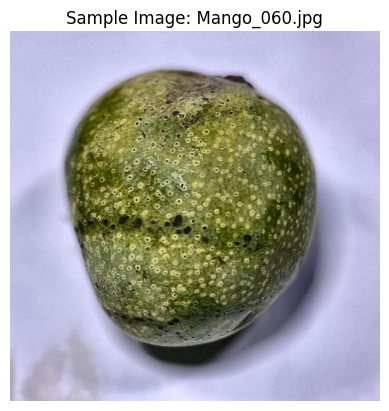

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Define the base path to the extracted dataset
base_dataset_path = '/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic\u00a0Segmentation/'

# Choose a sample image path. Let's pick a Mango image.
sample_image_path = os.path.join(base_dataset_path, 'Fruits', 'Mango', 'Mango_060.jpg')

# Check if the image exists
if os.path.exists(sample_image_path):
    # Load the image
    img = Image.open(sample_image_path)

    # Display the image
    plt.imshow(img)
    plt.title(f"Sample Image: {os.path.basename(sample_image_path)}")
    plt.axis('off') # Hide axes ticks and labels
    plt.show()
else:
    print(f"Error: Image not found at {sample_image_path}")
    print("Please verify the path or choose another sample image.")

### 1. Data Preparation: Loading the Image Dataset

We'll use `tf.keras.utils.image_dataset_from_directory` to load the images directly from the directory structure. This utility automatically infers labels from the subfolder names and splits the data into training and validation sets. We'll also define image dimensions and batch size.

In [13]:
import tensorflow as tf

# Define image dimensions and batch size
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

# The base path to your dataset, derived from the previous extraction step.
# Note: The path has a non-standard space character '\xa0' which needs to be handled.
base_dataset_path = '/content/dataset/Multi-Source Agricultural Image Dataset for Robust Classification and Semantic\u00a0Segmentation'

# Create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

# Create validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

# Get class names
class_names = train_ds.class_names
print(f"Found {len(class_names)} classes: {class_names}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 5405 files belonging to 4 classes.
Using 4324 files for training.
Found 5405 files belonging to 4 classes.
Using 1081 files for validation.
Found 4 classes: ['Crops or Grains', 'Flowers', 'Fruits', 'Vegetables']


### 2. Build the CNN Model

This is a basic CNN architecture with `Conv2D` layers, `MaxPooling2D` layers, `Flatten`, and `Dense` layers for classification. We'll also include a `Rescaling` layer to normalize pixel values and `Dropout` for regularization.

In [14]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.5), # Add dropout for regularization
  layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Train the Model

Now, let's train the CNN model using the prepared training and validation datasets. We'll train for a few epochs.

In [15]:
epochs = 10 # You can adjust the number of epochs
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)


Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 101s 669ms/step - accuracy: 0.4919 - loss: 1.1858 - val_accuracy: 0.6596 - val_loss: 0.8832
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 93s 686ms/step - accuracy: 0.6741 - loss: 0.7984 - val_accuracy: 0.7095 - val_loss: 0.7242
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 87s 639ms/step - accuracy: 0.7579 - loss: 0.6156 - val_accuracy: 0.7484 - val_loss: 0.6333
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 142s 641ms/step - accuracy: 0.8046 - loss: 0.5002 - val_accuracy: 0.8020 - val_loss: 0.4892
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 89s 654ms/step - accuracy: 0.8578 - loss: 0.3832 - val_accuracy: 0.8714 - val_loss: 0.3830
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 141s 648ms/step - accuracy: 0.8784 - loss: 0.3124 - val_accuracy: 0.8723 - val_loss: 0.3392
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 88s 648ms/step - accuracy: 0.9239 - loss: 0.2117 - val_accuracy: 0.8862 - val_loss: 0.3130
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 140s 637ms/step - accuracy: 0.9401 - los

### 4. Visualize Training Results (Optional)

We can visualize the training accuracy and loss over epochs to understand model performance.

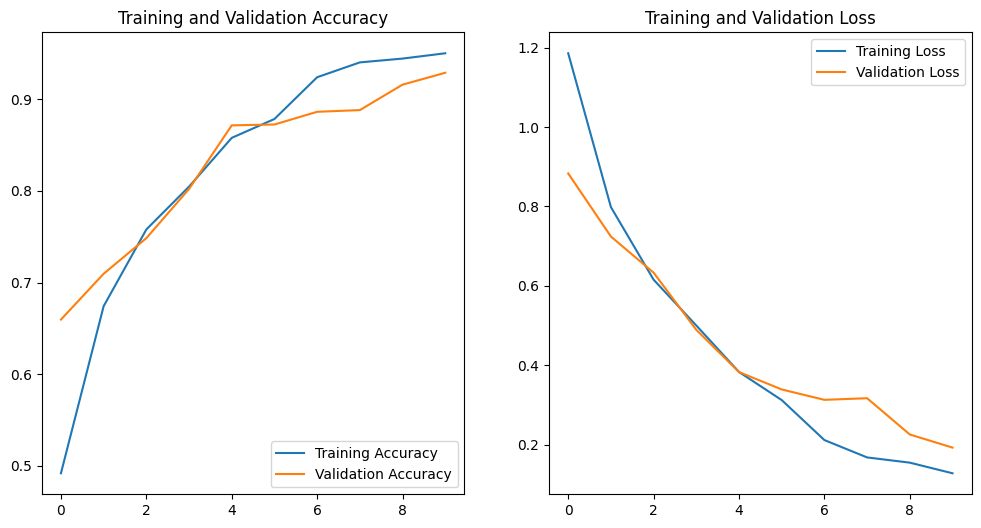

In [16]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [11]:
# Display the content of 'About Dataset.txt' to understand the dataset
with open('/content/dataset/About Dataset.txt', 'r') as f:
    print(f.read())

Dataset Metadata Summary

Dataset Name: Multi-Source Agricultural Image Dataset for Robust Classification and Semantic Segmentation
Total Images: 5,405
Total Categories: 4 (Crops/Grains, Flowers, Fruits, Vegetables)
Image Format: Standardized (e.g., JPEG, 256x256)
Images per Class: Mostly 70, some with 85
Folder Structure: Category / Class Name
Source: Collected manually

1. Crops or Grains (9 classes | 630 images)
Chickpeas: 70
Corn: 70
Linseed: 70
Mustard: 70
Red Lentil: 70
Rice: 70
Safflower: 70
Sunflower: 70
Wheat: 70

2. Flowers (26 classes | 1,835 images)
Brunfelsia: 70
China Rose: 70
Chinese Ixora: 70
Chrysanthemum: 70
Cockscomb: 70
Dahlia: 85
Damask Rose: 70
Garden Rose: 70
Garden Rose White: 70
Genda: 70
Hibiscus: 70
Ixora Coccinea: 70
Marigold: 70
Peace Rose: 70
Rangoon Creeper: 70
Rose Kristall: 70
Rose Landora: 70
Rose Veterans Honor: 70
Sacred Tree: 70
Scarlet Sage: 70
Shoeblack: 70
Silver flower: 70
Yellow Elder: 70
Yesterday-Today-Tomorrow: 70
Zinnia: 70

3. Fruits (20 c